In [ ]:
#Import libraries/dataset
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import timedelta

contacts_file = ("contacts.tsv")
contacts = pd.read_csv(contacts_file, sep="\t")

searches_file = ("searches.tsv")
searches = pd.read_csv(searches_file, sep="\t")

In [ ]:
# Assuming 'contacts' is your DataFrame
print('Total Number of Contacts:', len(contacts))
print("Total and Percent of Null Values:")
print(f"{'Column':<20} {'Total Nulls':>15} {'Percent Nulls':>15}")
for column in contacts.columns:
    total_nulls = contacts[column].isna().sum()
    percent_nulls = (total_nulls / len(contacts)) * 100
    if total_nulls != 0:
        print(f"{column:<20} {total_nulls:>15,} {percent_nulls:>14.2f}%")

Total Number of Contacts: 7823
Total and Percent of Null Values:
Column                   Total Nulls   Percent Nulls
ts_reply_at                      604           7.72%
ts_accepted_at                 4,196          53.64%
ts_booking_at                  5,649          72.21%


In [ ]:
#add a boolean that represents if the host accepted the inquirie
contacts['accepted'] = contacts['ts_accepted_at'].notna()

#add a boolean that represetns if the contact lead to a booking
contacts['booked'] = contacts['ts_booking_at'].notna()
contacts.head()

,id_guest,id_host,id_listing,ts_contact_at,ts_reply_at,ts_accepted_at,ts_booking_at,ds_checkin,ds_checkout,n_guests,n_messages,accepted,booked
0,000dfad9-459b-4f0b-8310-3d6ab34e4f57,13bb24b8-d432-43a2-9755-5ea11b43bb69,21d2b1a2-fdc3-4b4c-a1f0-0eaf0cc02370,2014-10-04 16:26:28.0,2014-10-04 16:26:28.0,2014-10-04 16:26:28.0,2014-10-04 16:26:28.0,2014-10-13,2014-10-15,2,13,True,True
1,00197051-c6cb-4c3a-99e9-86615b819874,46aa3897-9c00-4d76-ac66-a307593d0675,fb5ed09a-9848-4f2c-b2ef-34deb62164fb,2014-11-04 09:10:03.0,2014-11-04 09:45:50.0,2014-11-04 09:45:50.0,2014-11-04 12:20:46.0,2014-11-27,2014-11-30,1,10,True,True
2,0027538e-aa9e-4a02-8979-b8397e5d4cba,6bbb88ca-db66-48c5-9c4b-862f7706284a,d3871da6-8012-4dc4-b508-c91f2c10c297,2014-10-10 12:02:50.0,2014-10-10 15:07:01.0,NaN,NaN,2014-10-17,2014-10-19,2,3,False,False
3,0027538e-aa9e-4a02-8979-b8397e5d4cba,8772bc85-a9b7-4d85-a52d-41f3620c2912,0d9b5583-8053-4b67-adfe-8c29eb12efed,2014-10-10 15:23:53.0,NaN,NaN,NaN,2014-10-17,2014-10-19,2,2,False,False
4,0027538e-aa9e-4a02-8979-b8397e5d4cba,ac162061-55e2-4072-ac91-2e080f9581f2,ec68e0af-b0f2-42c7-b6f8-d41061c083ff,2014-10-10 15:22:26.0,2014-10-10 15:24:26.0,2014-10-10 15:24:26.0,2014-10-10 15:52:42.0,2014-10-17,2014-10-19,2,14,True,True


In [ ]:
# Prints total number of null values next to % null values
print('Total Number of Searches:', len(searches))
print("Total and Percent of Null Values:")
print(f"{'Column':<20} {'Total Nulls':>15} {'Percent Nulls':>15}")
for column in searches.columns:
    total_nulls = searches[column].isna().sum()
    percent_nulls = (total_nulls / len(searches)) * 100
    if total_nulls != 0:
        print(f"{column:<20} {total_nulls:>15,} {percent_nulls:>14.2f}%")

Total Number of Searches: 35737
Total and Percent of Null Values:
Column                   Total Nulls   Percent Nulls
ds_checkin                    11,849          33.16%
ds_checkout                   11,849          33.16%
n_nights                      11,849          33.16%
filter_price_min              22,415          62.72%
filter_price_max              22,415          62.72%
filter_room_types             19,546          54.69%
filter_neighborhoods          34,391          96.23%


In [ ]:
searches['filter_neighborhoods'].value_counts()

filter_neighborhoods
,City Centre                                                                                                                                                     719
,City Centre,Old City                                                                                                                                             46
,Temple Bar                                                                                                                                                       42
City Centre                                                                                                                                                       33
,City Centre,Temple Bar                                                                                                                                           29
                                                                                                                                                          

In [ ]:
def add_weekdays_column(df):
        """
        Adds a column 'weekdays' to the dataframe which lists the weekdays between check-in and check-out dates.
        """

        # Convert date columns to datetime objects
        df['ds_checkin'] = pd.to_datetime(df['ds_checkin'], errors='coerce')
        df['ds_checkout'] = pd.to_datetime(df['ds_checkout'], errors='coerce')

        # Function to calculate list of weekdays
        def get_weekdays(row):
            if pd.isnull(row['ds_checkin']) or pd.isnull(row['ds_checkout']):
                return None
            day_list = []
            current_day = row['ds_checkin']
            while current_day < row['ds_checkout']:
                day_list.append(current_day.strftime('%A'))
                current_day += timedelta(days=1)
            return day_list

        # Apply function to each row
        df['weekdays'] = df.apply(get_weekdays, axis=1)
        return df

def prob_B_given_A(df, column_B, column_A):
    """
    Calculate the conditional probability of B being True given A is True.

    Parameters:
    df (pd.DataFrame): DataFrame containing the boolean columns.
    column_A (str): Column name for A.
    column_B (str): Column name for B.

    Returns:
    float: Conditional probability P(B | A).
    """
    # Ensure columns exist in DataFrame
    if column_A not in df.columns or column_B not in df.columns:
        raise ValueError("One or both specified columns do not exist in the DataFrame.")

    # Count the number of true values in column A
    count_A = df[column_A].sum()

    # Count the number of rows where both A and B are true
    count_A_and_B = df[df[column_A] & df[column_B]].shape[0]

    # Calculate conditional probability P(B | A)
    if count_A == 0:
        return None  # To handle the case where P(A) is 0, hence P(B | A) is undefined
    conditional_probability = count_A_and_B / count_A

    return conditional_probability

def plot_weekdays_hist(df):
        all_weekdays = []
        for weekdays in df['weekdays'].dropna():
            all_weekdays.extend(weekdays)

        # Count the frequency of each weekday
        weekday_counts = pd.Series(all_weekdays).value_counts()

        # Sort by the day of the week starting from Monday
        weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        weekday_counts = weekday_counts.reindex(weekday_order, fill_value=0)

        # Plotting the histogram
        plt.figure(figsize=(10, 6))
        weekday_counts.plot(kind='bar', color='skyblue')
        plt.title('Frequency of Weekdays in Bookings')
        plt.xlabel('Weekday')
        plt.ylabel('Frequency')
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
        return

def plot_bookings_by_month(df,date_column,image_path):
        """
        Plot the number of bookings by month from the specified date column in a DataFrame.

        Parameters:
        df (pd.DataFrame): The DataFrame containing the booking data.
        date_column (str): The column name that contains the date data.
        """
        # Convert the specified column to datetime format, if not already
        df[date_column] = pd.to_datetime(df[date_column], errors='coerce')

        # Drop rows where the date is NaT (not a time, i.e., missing or invalid dates)
        df = df.dropna(subset=[date_column])

        # Extract year and month from the date
        df['YearMonth'] = df[date_column].dt.to_period('M')

        # Count the number of bookings per month
        monthly_counts = df['YearMonth'].value_counts().sort_index()

        # Plot the data
        plt.figure(figsize=(12, 6))
        monthly_counts.plot(kind='bar', color='teal')
        plt.title('Number of Bookings by Month')
        plt.xlabel('Month')
        plt.ylabel('Number of Bookings')
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        if image_path is None:
            plt.show()
        else:
            plt.savefig(Path(image_path))
            plt.close()
        return

In [ ]:
#add a boolean that represents if the host accepted the inquirie
contacts['accepted'] = contacts['ts_accepted_at'].notna()

#add a boolean that represetns if the contact lead to a booking
contacts['booked'] = contacts['ts_booking_at'].notna()

print(f"Probability of booking given the inquirie was accepted {prob_B_given_A(contacts,'booked','accepted')}")

Probability of booking given the inquirie was accepted 0.5993934381031155


In [ ]:
#convert ds to datetime pandas frame
searches['ds'] = pd.to_datetime(searches['ds'])

#add column for what days of the week they're searching for
searches = add_weekdays_column(searches)
contacts = add_weekdays_column(contacts)

# add column for how soon they want the room
searches['length_preperation'] = searches['ds_checkin'] - searches['ds']


In [ ]:
searches.head()

,ds,id_user,ds_checkin,ds_checkout,n_searches,n_nights,n_guests_min,n_guests_max,origin_country,filter_price_min,filter_price_max,filter_room_types,filter_neighborhoods,weekdays,length_preperation
0,2014-10-01,0000af0a-6f26-4233-9832-27efbfb36148,2014-10-09,2014-10-12,16,3.0,2,2,IE,0.0,67.0,",Entire home/apt,Entire home/apt,Private room,...",NaN,"[Thursday, Friday, Saturday]",8 days
1,2014-10-01,0000af0a-6f26-4233-9832-27efbfb36148,2014-10-09,2014-10-19,3,10.0,1,2,IE,0.0,67.0,NaN,NaN,"[Thursday, Friday, Saturday, Sunday, Monday, T...",8 days
2,2014-10-01,000cd9d3-e05b-4016-9e09-34a6f8ba2fc5,NaT,NaT,1,NaN,1,1,GB,NaN,NaN,NaN,NaN,None,NaT
3,2014-10-01,000cd9d3-e05b-4016-9e09-34a6f8ba2fc5,2014-11-08,2014-11-10,11,2.0,1,2,GB,NaN,NaN,",Entire home/apt",NaN,"[Saturday, Sunday]",38 days
4,2014-10-01,001c04f0-5a94-4ee0-bf5d-3591265256de,NaT,NaT,1,NaN,1,1,IE,NaN,NaN,NaN,NaN,None,NaT


In [ ]:
#add a boolean that represents if the host accepted the inquirie
contacts['accepted'] = contacts['ts_accepted_at'].notna()
#add a boolean that represetns if the contact lead to a booking

contacts['booked'] = contacts['ts_booking_at'].notna()
contacts.head()

,id_guest,id_host,id_listing,ts_contact_at,ts_reply_at,ts_accepted_at,ts_booking_at,ds_checkin,ds_checkout,n_guests,n_messages,accepted,booked,weekdays
0,000dfad9-459b-4f0b-8310-3d6ab34e4f57,13bb24b8-d432-43a2-9755-5ea11b43bb69,21d2b1a2-fdc3-4b4c-a1f0-0eaf0cc02370,2014-10-04 16:26:28.0,2014-10-04 16:26:28.0,2014-10-04 16:26:28.0,2014-10-04 16:26:28.0,2014-10-13,2014-10-15,2,13,True,True,"[Monday, Tuesday]"
1,00197051-c6cb-4c3a-99e9-86615b819874,46aa3897-9c00-4d76-ac66-a307593d0675,fb5ed09a-9848-4f2c-b2ef-34deb62164fb,2014-11-04 09:10:03.0,2014-11-04 09:45:50.0,2014-11-04 09:45:50.0,2014-11-04 12:20:46.0,2014-11-27,2014-11-30,1,10,True,True,"[Thursday, Friday, Saturday]"
2,0027538e-aa9e-4a02-8979-b8397e5d4cba,6bbb88ca-db66-48c5-9c4b-862f7706284a,d3871da6-8012-4dc4-b508-c91f2c10c297,2014-10-10 12:02:50.0,2014-10-10 15:07:01.0,NaN,NaN,2014-10-17,2014-10-19,2,3,False,False,"[Friday, Saturday]"
3,0027538e-aa9e-4a02-8979-b8397e5d4cba,8772bc85-a9b7-4d85-a52d-41f3620c2912,0d9b5583-8053-4b67-adfe-8c29eb12efed,2014-10-10 15:23:53.0,NaN,NaN,NaN,2014-10-17,2014-10-19,2,2,False,False,"[Friday, Saturday]"
4,0027538e-aa9e-4a02-8979-b8397e5d4cba,ac162061-55e2-4072-ac91-2e080f9581f2,ec68e0af-b0f2-42c7-b6f8-d41061c083ff,2014-10-10 15:22:26.0,2014-10-10 15:24:26.0,2014-10-10 15:24:26.0,2014-10-10 15:52:42.0,2014-10-17,2014-10-19,2,14,True,True,"[Friday, Saturday]"


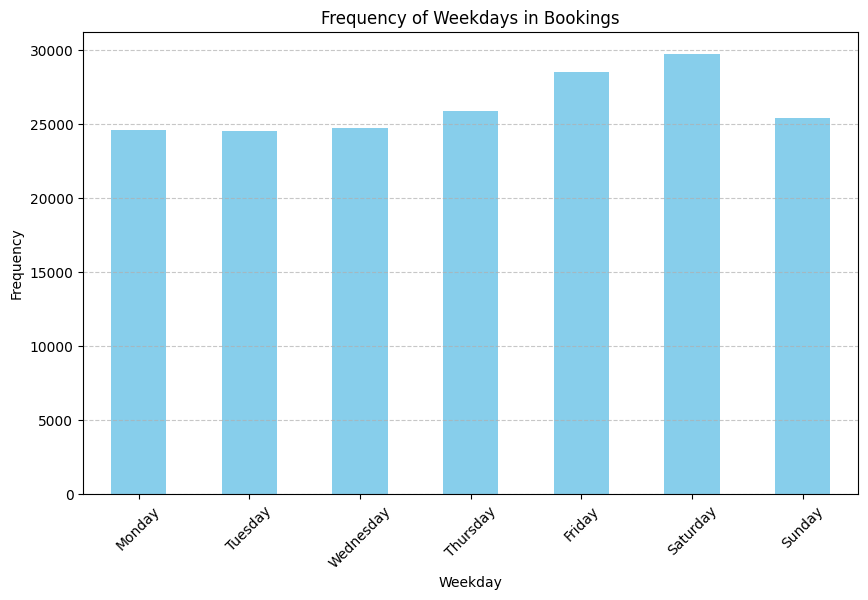

In [ ]:
plot_weekdays_hist(searches)

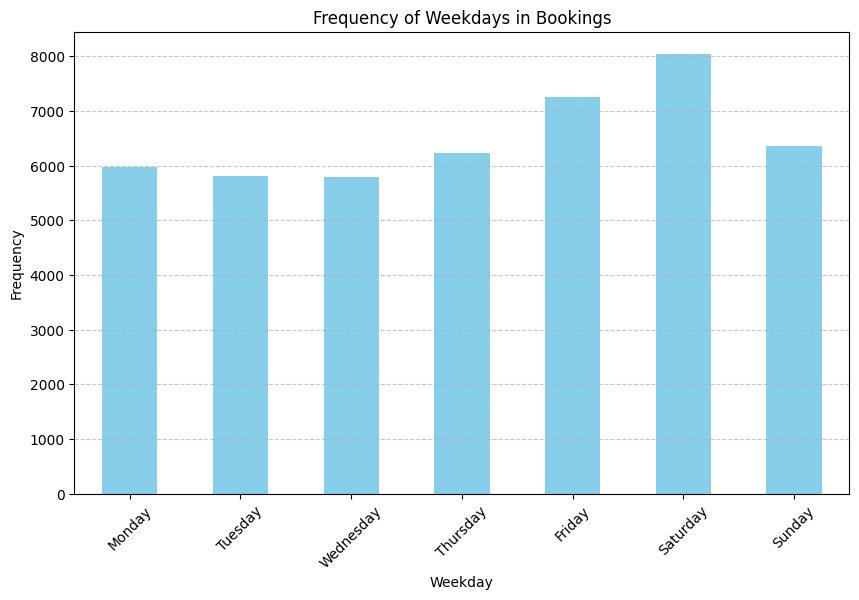

In [ ]:
plot_weekdays_hist(contacts)

In [ ]:
#plot_bookings_by_month(contacts,'ds_checkin','l')

In [ ]:
#plot_bookings_by_month(searches,'ds_checkin','l')

In [ ]:
# Prints total number of null values next to % null values
print('Total Number of Searches:', len(searches))
print("Total and Percent of Null Values:")
print(f"{'Column':<20} {'Total Nulls':>15} {'Percent Nulls':>15}")
for column in searches.columns:
    total_nulls = searches[column].isna().sum()
    percent_nulls = (total_nulls / len(searches)) * 100
    if total_nulls != 0:
        print(f"{column:<20} {total_nulls:>15,} {percent_nulls:>14.2f}%")

Total Number of Searches: 35737
Total and Percent of Null Values:
Column                   Total Nulls   Percent Nulls
ds_checkin                    11,849          33.16%
ds_checkout                   11,849          33.16%
n_nights                      11,849          33.16%
filter_price_min              22,415          62.72%
filter_price_max              22,415          62.72%
filter_room_types             19,546          54.69%
filter_neighborhoods          34,391          96.23%
weekdays                      11,849          33.16%
length_preperation            11,849          33.16%


In [ ]:
#Drop filter_neighborhoods column
#MAYBE DONT USE THIS?
searches = searches.drop(columns=['filter_neighborhoods'])

In [ ]:
display(contacts.describe())

,ds_checkin,ds_checkout,n_guests,n_messages
count,7823,7823,7823.000000,7823.000000
mean,2014-11-16 09:47:00.452511744,2014-11-22 05:12:33.317141760,2.422600,6.319954
min,2014-10-01 00:00:00,2014-10-02 00:00:00,1.000000,1.000000
25%,2014-10-15 00:00:00,2014-10-19 00:00:00,1.000000,2.000000
50%,2014-10-31 00:00:00,2014-11-06 00:00:00,2.000000,4.000000
75%,2014-11-22 00:00:00,2014-11-30 00:00:00,3.000000,8.000000
max,2015-10-24 00:00:00,2015-12-01 00:00:00,16.000000,102.000000
std,NaN,NaN,1.617347,6.472827


In [ ]:
display(contacts.skew(axis = 0, numeric_only = True, skipna = True))

n_guests      2.441468
n_messages    3.696440
accepted      0.145883
booked        0.991796
dtype: float64

In [ ]:
display(searches.describe())

,ds,ds_checkin,ds_checkout,n_searches,n_nights,n_guests_min,n_guests_max,filter_price_min,filter_price_max,length_preperation
count,35737,23888,23888,35737.000000,23888.000000,35737.000000,35737.000000,13322.000000,1.332200e+04,23888
mean,2014-10-07 14:32:34.478551552,2014-11-27 22:42:10.609511168,2014-12-05 14:50:57.468184832,9.206565,7.672765,1.742955,2.105857,8.470200,9.019063e+07,51 days 08:11:53.730743469
min,2014-10-01 00:00:00,2014-10-01 00:00:00,2014-10-02 00:00:00,1.000000,0.000000,1.000000,1.000000,0.000000,9.000000e+00,-1 days +00:00:00
25%,2014-10-04 00:00:00,2014-10-17 00:00:00,2014-10-23 00:00:00,1.000000,2.000000,1.000000,1.000000,0.000000,8.600000e+01,10 days 00:00:00
50%,2014-10-08 00:00:00,2014-11-03 00:00:00,2014-11-09 00:00:00,4.000000,3.000000,1.000000,2.000000,0.000000,1.390000e+02,26 days 00:00:00
75%,2014-10-11 00:00:00,2014-12-13 00:00:00,2014-12-24 00:00:00,10.000000,5.000000,2.000000,2.000000,0.000000,3.010000e+02,67 days 00:00:00
max,2014-10-14 00:00:00,2016-06-02 00:00:00,2016-08-17 00:00:00,448.000000,399.000000,16.000000,16.000000,1250.000000,1.073742e+09,604 days 00:00:00
std,NaN,NaN,NaN,17.348746,21.557614,1.460440,1.817358,53.987679,2.978482e+08,65 days 18:56:19.491940518


In [ ]:
display(searches.skew(axis = 0, numeric_only = True, skipna = True))

n_searches           7.509258
n_nights             9.942364
n_guests_min         3.583798
n_guests_max         3.148548
filter_price_min    11.087745
filter_price_max     2.999833
dtype: float64

In [ ]:
# Getting the summary stats for ppl who tried to contact but did not get a response
# ppl in contacts.tsv such that guest contacts but no booking

# order is guest contacts -> host replies -> host accepts -> booking is made

# factors of guests that influence inquiries that do and don't lead to bookings from contacts
# number of hosts that a guest contacts

not_accepted_df = contacts[contacts['accepted'] == False]
guests_not_accepted = not_accepted_df['id_guest'].unique()
len(guests_not_accepted)

# factors: n_nights, n_guests

sub_df = searches[searches['id_user'].isin(guests_not_accepted)]

In [ ]:
# use contacts dataframe
# Find count number of country mentioned in data, what is % of that count get a booking
# Group countries with similar % together
# Create model to predict booking with those grouped_countries as explanatory indicator (1 if individual from that group or 0 if not) variables

searches = searches.rename(columns ={'id_user':'id_guest'})
df_merged = pd.merge(contacts, searches[['id_guest','origin_country']], on='id_guest')
df_merged = df_merged.dropna(subset=['origin_country'])
df_merged.reset_index(drop=True, inplace=True)
proportion_countries = df_merged['origin_country'].value_counts()
df_merged['ts_contact_at']



0        2014-10-04 16:26:28.0
1        2014-11-04 09:10:03.0
2        2014-10-10 12:02:50.0
3        2014-10-10 12:02:50.0
4        2014-10-10 15:23:53.0
                 ...          
28531    2014-10-07 21:30:31.0
28532    2014-10-08 00:05:05.0
28533    2014-10-08 00:05:05.0
28534    2014-10-08 00:05:05.0
28535    2014-10-08 00:05:05.0
Name: ts_contact_at, Length: 28536, dtype: object

In [ ]:
proportion_countries

origin_country
US    4298
GB    3667
FR    3232
IT    3137
IE    2951
      ... 
IM       2
LS       2
EC       1
RE       1
ET       1
Name: count, Length: 72, dtype: int64

In [ ]:
searches['filter_neighborhoods'].count()

KeyError: 'filter_neighborhoods'

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=53f57b5b-40bf-4d3c-80c6-09cde8cf8988' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>